In [21]:
# Notebook d'évaluation du modèle XGBoost sur le test set 

# Méthodologie :

# Comparaison avec un modèle "naïf" :
#   - Pour un point donné t, la prédiction correspond à la valeur observée 
#     au même moment la semaine précédente :
#       P_naive(t) = P(t - 972 points)

# 1. Évaluation de la prédiction de la consommation 24h :
#    - Metrics : 
#        * MAE globale sur tous les horizons
#        * MAE par horizon (chaque pas de 15 min)

# 2. Évaluation en mode "production" (backtest) :
#    - La prédiction est réactualisée toutes les heures
#    - À chaque temps t, seules les 4 prédictions suivantes sont utilisées
#    - Metrics : MAE
#    - Analyse graphique : courbe réelle vs prédit à différentes échelles temporelles (heure, jour, semaine)


In [22]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from src.forecast.utils.data_processing import prediction_in_production
from src.forecast.utils.features_engineering import compute_mean_freq_dynamic
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [23]:
#chargement des prédictions
data = joblib.load("../predictions/predictions.pkl")
X_test = data["X_test"]
y_pred_model = data["y_pred_model"]
y_pred_naive = data["y_pred_naive"]
y_test = data["y_test"]


In [24]:
#1. Evaluation de la prédiction 24h

# calcul des MAEs tout horizon confondu
mean_error_naif = mean_absolute_error(y_pred_naive[:-96, :], y_test.iloc[:-96, :])
mean_error = mean_absolute_error(y_pred_model[:-96, :], y_test.iloc[:-96, :])

#calcul de la puissance moyenne sur ces 24h
mean_consumption=np.mean(y_test)

print(f"La MAE sur tous les horizons du modèle naif est de {mean_error_naif:.0f} MW contre  {mean_error:.0f} MW pour le modèle Xgboost : Xgboost est plus performant que le modèle naif, tout horizon confondu avec un taux d'erreur relatif par rapport à la consommation moyenne  sur la période ({round(mean_consumption)}MW)de :{mean_error/mean_consumption*100: .1f} %.")


La MAE sur tous les horizons du modèle naif est de 2771 MW contre  1632 MW pour le modèle Xgboost : Xgboost est plus performant que le modèle naif, tout horizon confondu avec un taux d'erreur relatif par rapport à la consommation moyenne  sur la période (45160MW)de : 3.6 %.


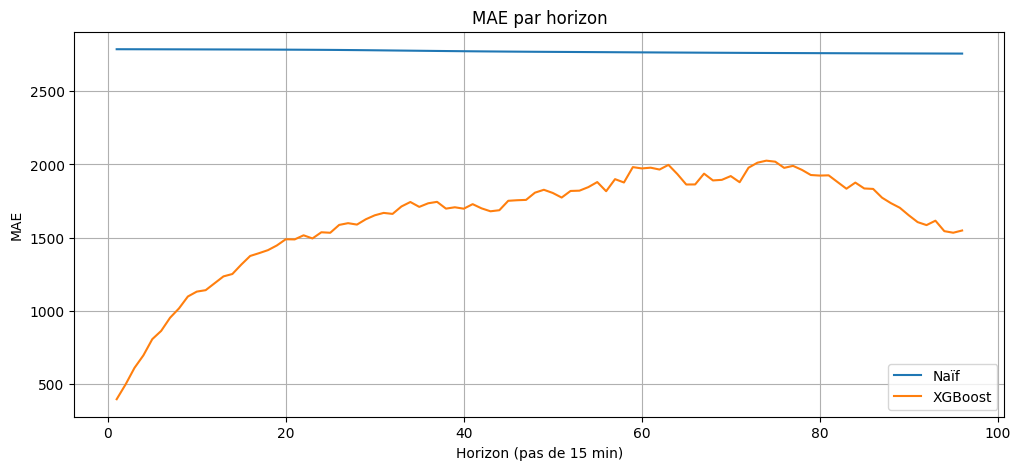

La MAE augmente avec l'horizon pour le modèle Xgboost pour redescendre sur la prédiction pendant la nuit


In [25]:
# calcul des MAES par horizon
horizon = y_test.shape[1]

mae_naive_per_horizon = [mean_absolute_error(y_test.iloc[:-96, i], y_pred_naive[:-96, i])
                          for i in range(horizon)]

mae_model_per_horizon = [mean_absolute_error(y_test.iloc[:-96, i], y_pred_model[:-96, i])
                         for i in range(horizon)]


#Illustration
plt.figure(figsize=(12,5))
plt.plot(range(1, horizon+1), mae_naive_per_horizon, label="Naïf")
plt.plot(range(1, horizon+1), mae_model_per_horizon, label="XGBoost")
plt.xlabel("Horizon (pas de 15 min)")
plt.ylabel("MAE")
plt.title("MAE par horizon")
plt.legend()
plt.grid(True)
plt.show()

print("La MAE augmente avec l'horizon pour le modèle Xgboost pour redescendre sur la prédiction pendant la nuit")


In [26]:
#2. Évaluation en mode "production" (backtest) :
#On simule le comportement en production, prédiction réactualisée toutes les heures (on prend que les 4 premiers points de chaque courbe de prédiction 24h)
step_hour=4
# valeurs prédites en production
y_pred_forecast=prediction_in_production(y_pred_model,step_hour)

#construction de test pour contenir toutes les prédictions (model, naif) et valeurs réelles
test=X_test
test["y_pred"] = y_pred_forecast
test["y_naif"]=test["Consommation_lag_672"]
test["y_true"]=test["Consommation"]
test['timestamp'] = pd.to_datetime(test[['year', 'month', 'day', 'hour', 'minute']])


In [27]:
#calcul de la MAE en production
mean_error = mean_absolute_error(test["y_pred"], test["y_true"])

mean_power=test["y_true"].mean()
print(f"MAE en production : {mean_error:.0f} soit en % puissance moyenne sur la période {mean_error/mean_power*100:.0f}%")
print("L'amélioration avec le modèle xgboost est significative par rapport à prendre la même valeur la semaine d'avant, on passe d'une erreur de puissance de 160 à 47")

MAE en production : 610 soit en % puissance moyenne sur la période 1%
L'amélioration avec le modèle xgboost est significative par rapport à prendre la même valeur la semaine d'avant, on passe d'une erreur de puissance de 160 à 47


In [28]:
#Analyse Graphiques


#calcule les moyennes de puissance sur differentes frequences pour visualiser là où le modèle se trompe
test=compute_mean_freq_dynamic(test,"y_true")
test=compute_mean_freq_dynamic(test,"y_pred")
test=compute_mean_freq_dynamic(test,"y_naif")

y_true_year_avg
y_true_month_avg
y_true_day_avg
y_true_hour_avg
y_true_minute_avg
y_true_week_avg
y_pred_year_avg
y_pred_month_avg
y_pred_day_avg
y_pred_hour_avg
y_pred_minute_avg
y_pred_week_avg
y_naif_year_avg
y_naif_month_avg
y_naif_day_avg
y_naif_hour_avg
y_naif_minute_avg
y_naif_week_avg


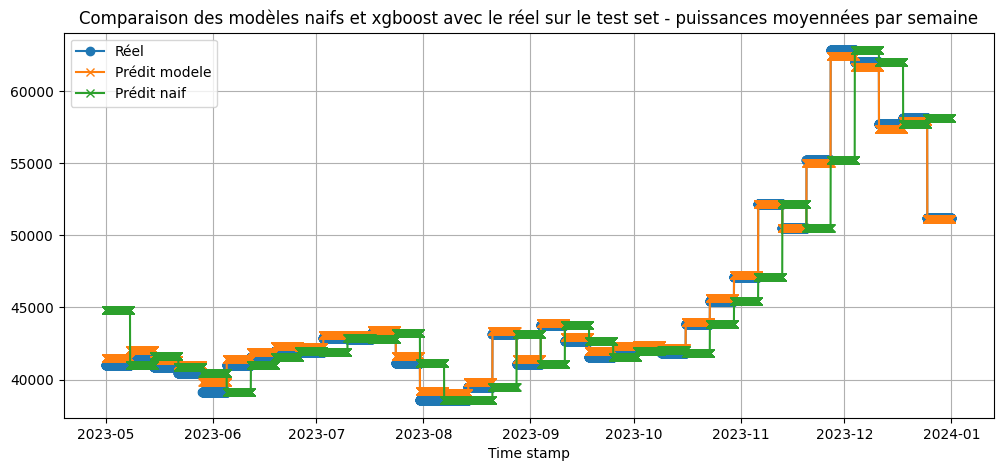

In [29]:
#Tracer les puissances moeyennes par week pour voir l'écart

# Plot
plt.figure(figsize=(12,5))
plt.plot(test["timestamp"], test["y_true_week_avg"], label="Réel", marker='o')
plt.plot(test["timestamp"], test["y_pred_week_avg"], label="Prédit modele", marker='x')
plt.plot(test["timestamp"], test["y_naif_week_avg"], label="Prédit naif", marker='x')
plt.xlabel("Time stamp")
#plt.ylabel(column_y)
plt.title("Comparaison des modèles naifs et xgboost avec le réel sur le test set - puissances moyennées par semaine")
plt.legend()
plt.grid(True)
plt.show()


Le modèle naïf montre un décalage d’une semaine par rapport aux valeurs réelles, comme prévu (par définition).  
Le modèle XGBoost suit la courbe réelle.


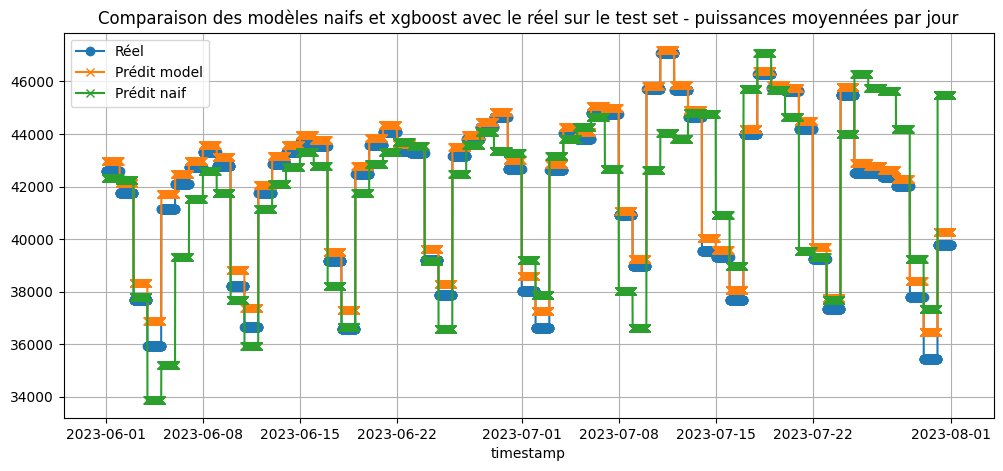

In [30]:
#Comparaison des puissances journalières
start = pd.Timestamp("2023-06-01")
end = pd.Timestamp("2023-08-01")  # exclusif
subset = test[(test["timestamp"] >= start) & (test["timestamp"] < end)]

# 4️⃣ Plot
plt.figure(figsize=(12,5))
plt.plot(subset["timestamp"], subset["y_true_day_avg"], label="Réel", marker='o')
plt.plot(subset["timestamp"], subset["y_pred_day_avg"], label="Prédit model", marker='x')
plt.plot(subset["timestamp"], subset["y_naif_day_avg"], label="Prédit naif", marker='x')

plt.xlabel("timestamp")
#plt.ylabel(column_y)
plt.title("Comparaison des modèles naifs et xgboost avec le réel sur le test set - puissances moyennées par jour")
plt.legend()
plt.grid(True)
plt.show()

Le modèle xgbost semble bien capter les variations journalières.

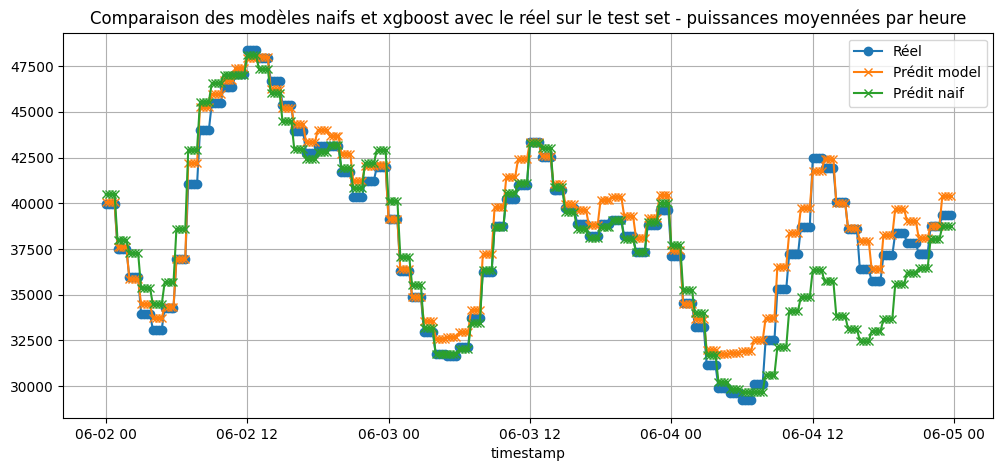

In [31]:
# puissances moyennées par heure"

start = pd.Timestamp("2023-06-02")
end = pd.Timestamp("2023-06-05")  # exclusif
subset = test[(test["timestamp"] >= start) & (test["timestamp"] < end)]

# Plot
plt.figure(figsize=(12,5))
plt.plot(subset["timestamp"], subset["y_true_hour_avg"], label="Réel", marker='o')
plt.plot(subset["timestamp"], subset["y_pred_hour_avg"], label="Prédit model", marker='x')
plt.plot(subset["timestamp"], subset["y_naif_hour_avg"], label="Prédit naif", marker='x')

plt.xlabel("timestamp")
#plt.ylabel(column_y)
plt.title("Comparaison des modèles naifs et xgboost avec le réel sur le test set - puissances moyennées par heure")
plt.legend()
plt.grid(True)
plt.show()

Le modèle XG boost semble bien capter les variations de puissances horaires.

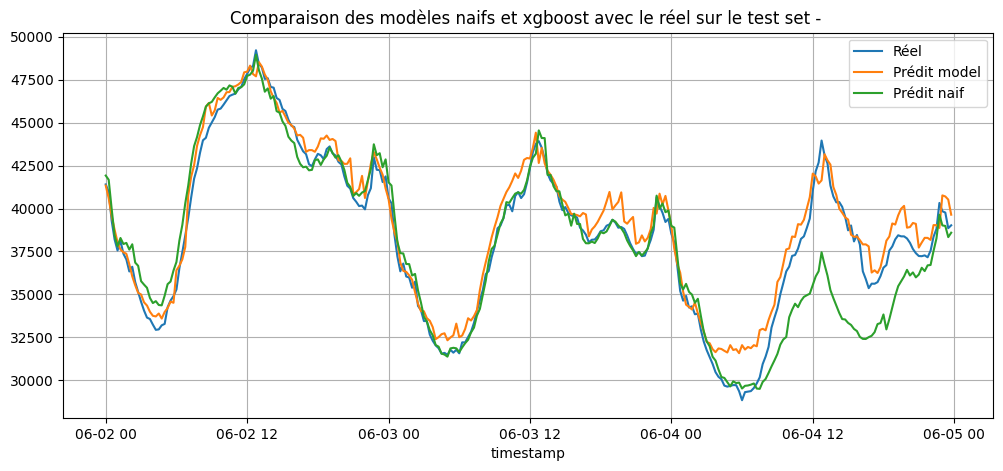

In [32]:
# puissances moyennées par heure"

start = pd.Timestamp("2023-06-02")
end = pd.Timestamp("2023-06-05")  # exclusif
subset = test[(test["timestamp"] >= start) & (test["timestamp"] < end)]

# Plot
plt.figure(figsize=(12,5))
plt.plot(subset["timestamp"], subset["y_true"], label="Réel")
plt.plot(subset["timestamp"], subset["y_pred"], label="Prédit model")
plt.plot(subset["timestamp"], subset["y_naif"], label="Prédit naif")

plt.xlabel("timestamp")
#plt.ylabel(column_y)
plt.title("Comparaison des modèles naifs et xgboost avec le réel sur le test set - ")
plt.legend()
plt.grid(True)
plt.show()